In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


In [62]:
df = pd.read_csv(r'insurance_data.csv')
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


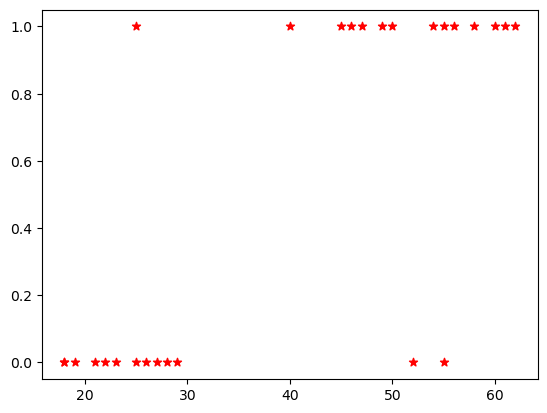

In [63]:
plt.scatter(df.age, df.bought_insurance, marker='*', color='red')

In [64]:
x = df[['age']]
y = df[['bought_insurance']]

In [65]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [66]:
x_test

,age
15,55
4,46
9,61
2,47
5,56
13,29


In [67]:
model = LogisticRegression()
model.fit(x_train, y_train)

c:\Users\raksh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [68]:
model.coef_

array([[0.1137385]])

In [69]:
model.intercept_

array([-4.64566346])

In [70]:
y_predicted = model.predict(x_test)

In [71]:
y_predicted

array([1, 1, 1, 1, 1, 0])

In [72]:
df['probs'] = model.predict_proba(df[['age']])[:,1]
df.head()

,age,bought_insurance,probs
0,22,0,0.104948
1,25,0,0.141583
2,47,1,0.668198
3,52,0,0.780527
4,46,1,0.642518


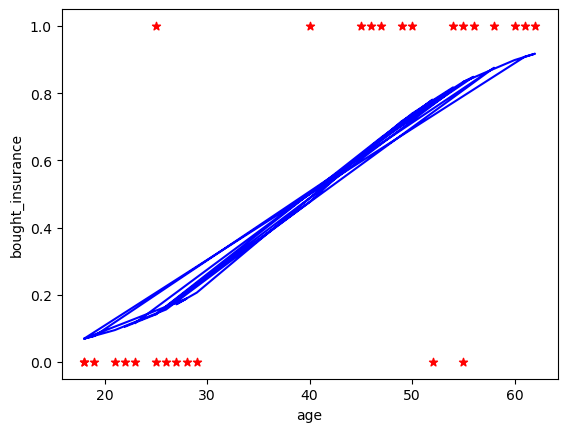

In [73]:
plt.scatter(df.age, df.bought_insurance, marker='*', color='red')
plt.xlabel('age')
plt.ylabel('bought_insurance')
plt.plot(df.age, df.probs, color='blue')
plt.show()

In [74]:
import math
def sigmoid(x):
    return 1 / (1 + math.exp(-x))   
def predict(age):
    z = model.coef_ * age + model.intercept_
    y = sigmoid(z)
    return y

In [75]:
age = 35
predict(age)

C:\Users\raksh\AppData\Local\Temp\ipykernel_9236\3833672348.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (1 + math.exp(-x))


0.33965862666695895

In [76]:
age = 40
predict(age)

C:\Users\raksh\AppData\Local\Temp\ipykernel_9236\3833672348.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (1 + math.exp(-x))


0.4759876496297182

In [77]:
age = 57
predict(age)

C:\Users\raksh\AppData\Local\Temp\ipykernel_9236\3833672348.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (1 + math.exp(-x))


0.8626446168144859

In [78]:
age = 66
predict(age)

C:\Users\raksh\AppData\Local\Temp\ipykernel_9236\3833672348.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (1 + math.exp(-x))


0.9458884878049404

In [79]:
age = 77
predict(age)

C:\Users\raksh\AppData\Local\Temp\ipykernel_9236\3833672348.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (1 + math.exp(-x))


0.9838920184668793

In [80]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x)
accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8518518518518519
